CPU times: user 32.8 s, sys: 17 s, total: 49.8 s
Wall time: 52.1 s


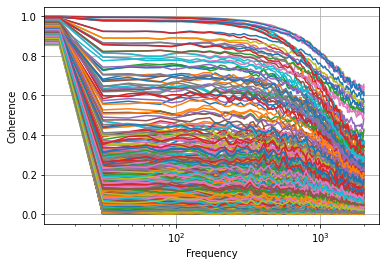

In [3]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
# Name_BCM = "Learned_BCM"
# time_now_BCM = "09:15"
# Name_No_BCM = "No_BCM"
# time_now_No_BCM = "09:47"
# date = "06-07"
Name_BCM = "Learned_BCM"
time_now_BCM = "21:54"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "15:10"
date = "06-10"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

f_No_BCM = [[]]*Params.N_Cells_PC
f_During_BCM = [[]]*Params.N_Cells_PC
f_BCM = [[]]*Params.N_Cells_PC
f_Coupled_No_BCM = [[]]*Params.N_Cells_PC
f_Coupled_During_BCM = [[]]*Params.N_Cells_PC
f_Coupled_BCM = [[]]*Params.N_Cells_PC
cxy_No_BCM = [[]]*Params.N_Cells_PC
cxy_During_BCM = [[]]*Params.N_Cells_PC
cxy_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    f_No_BCM[ii] = [[]]*Params.N_Noise
    f_During_BCM[ii] = [[]]*Params.N_Noise
    f_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_BCM[ii] = [[]]*Params.N_Noise
    cxy_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):     
        cxy_No_BCM[ii][jj], f_No_BCM[ii][jj] = cohere(PC_No_BCM.I_Noise[ii]/nA, Noise_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_During_BCM[ii][jj], f_During_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][:len(PC_BCM.I_Noise[ii])//2]/nA, Noise_Extended_BCM.I[jj][:len(Noise_Extended_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_BCM[ii][jj], f_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][len(PC_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_BCM.I[jj][len(Noise_Extended_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_No_BCM[ii][jj], f_Coupled_No_BCM[ii][jj] = cohere(PC_Coupled_No_BCM.I_Noise[ii]/nA, Noise_Coupled_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_During_BCM[ii][jj], f_Coupled_During_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][:len(PC_Coupled_BCM.I_Noise[ii])//2]/nA, Noise_Extended_Coupled_BCM.I[jj][:len(Noise_Extended_Coupled_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_BCM[ii][jj], f_Coupled_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][len(PC_Coupled_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_Coupled_BCM.I[jj][len(Noise_Extended_Coupled_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
    xscale('log')
    
mean_point_cxy_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    mean_point_cxy_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):
        idx_aa = []
        for kk in range(0,len(f_No_BCM[ii][jj])):
            if 10**2 <= f_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_No_BCM[ii][jj] = mean(cxy_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_During_BCM[ii][jj])):
            if 10**2 <= f_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_During_BCM[ii][jj] = mean(cxy_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_BCM[ii][jj])):
            if 10**2 <= f_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_BCM[ii][jj] = mean(cxy_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_No_BCM[ii][jj])):
            if 10**2 <= f_Coupled_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_No_BCM[ii][jj] = mean(cxy_Coupled_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_During_BCM[ii][jj])):
            if 10**2 <= f_Coupled_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_During_BCM[ii][jj] = mean(cxy_Coupled_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_BCM[ii][jj])):
            if 10**2 <= f_Coupled_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_BCM[ii][jj] = mean(cxy_Coupled_BCM[ii][jj][idx_aa])
        

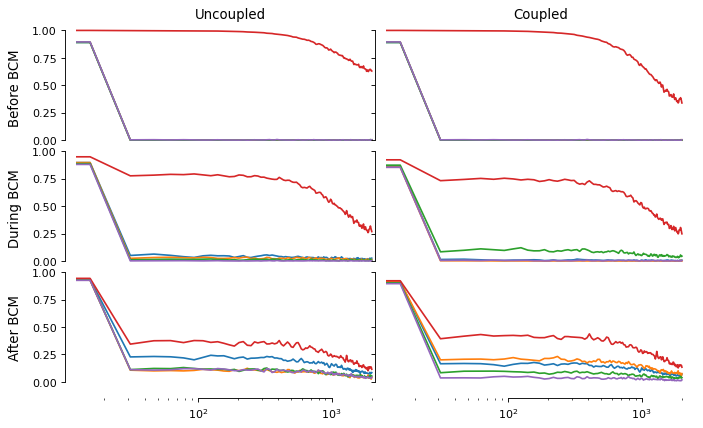

In [18]:
ii = 0
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
fig, axs = plt.subplots(3,2, figsize=(10, 6), sharex=True, sharey=True, dpi= 80, facecolor='w', edgecolor='k')
fig.subplots_adjust(hspace = .001, wspace=.001)
col = 0
axs = axs.ravel()
axs[0].set_title('Uncoupled')
axs[1].set_title('Coupled')
for jj in range(0,Params.N_Noise):
    axs[col].plot(f_No_BCM[ii][jj],cxy_No_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col].set_xlabel('')
axs[col].set_xticklabels([])
axs[col].set_ylabel('')
axs[col].set_xscale('log')
# axs[col].grid(True)
# axs[col].text(0.05, 0.9, 'PC '+str(ii+1), transform=axs[ii*col].transAxes, fontsize=14, verticalalignment='top', bbox=props)
for jj in range(0,Params.N_Noise):     
    axs[col+2].plot(f_During_BCM[ii][jj],cxy_During_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+2].set_xticklabels([])
axs[col+2].set_ylabel('')
axs[col+2].set_xlabel('')
axs[col+2].set_xscale('log')
# axs[col+2].grid(True)
for jj in range(0,Params.N_Noise):     
    axs[col+4].plot(f_BCM[ii][jj],cxy_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+4].set_xticklabels([])
axs[col+4].set_ylabel('')
axs[col+4].set_xlabel('')
axs[col+4].set_xscale('log')
# axs[col+4].grid(True)
# axs[col+2].axvline(x=2100,ymin=-1.5,ymax=1.5,c="red",linewidth=4,zorder=0, clip_on=True)
for jj in range(0,Params.N_Noise):     
    axs[col+1].plot(f_Coupled_No_BCM[ii][jj],cxy_Coupled_No_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+1].set_xlabel('')
axs[col+1].set_xticklabels([])
axs[col+1].set_ylabel('')
axs[col+1].set_xscale('log')
# axs[col+1].grid(True)
for jj in range(0,Params.N_Noise):     
    axs[col+3].plot(f_Coupled_During_BCM[ii][jj],cxy_Coupled_During_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+3].set_xticklabels([])
axs[col+3].set_ylabel('')
axs[col+3].set_xlabel('')
axs[col+3].set_xscale('log')
# axs[col+3].grid(True)
for jj in range(0,Params.N_Noise):     
    axs[col+5].plot(f_Coupled_BCM[ii][jj],cxy_Coupled_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+5].set_xticklabels([])
axs[col+5].set_ylabel('')
axs[col+5].set_xlabel('')
axs[col+5].set_xscale('log')
# axs[col+5].grid(True)
# axs[col-1].legend(loc='upper right')
# fig.text(0.5, 1.2, 'Coherence of PSC of PC', ha='center', rotation='horizontal', fontsize='large')
# fig.text(0.33, 1.05, 'Uncoupled', ha='center', rotation='horizontal', fontsize='large')
# fig.text(0.66, 1.05, 'Coupled', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.04, 0.75, 'Before BCM', va='center', rotation='vertical', fontsize='large')
fig.text(0.04, 0.5, 'During BCM', va='center', rotation='vertical', fontsize='large')
fig.text(0.04, 0.25, 'After BCM', va='center', rotation='vertical', fontsize='large')
# fig.text(0.5, -0.2, 'Frequency [Hz]', ha='center', rotation='horizontal', fontsize='large')
plt.ylim([-0.05, 1.05])
sns.despine(offset=10, trim=True)
plt.show()

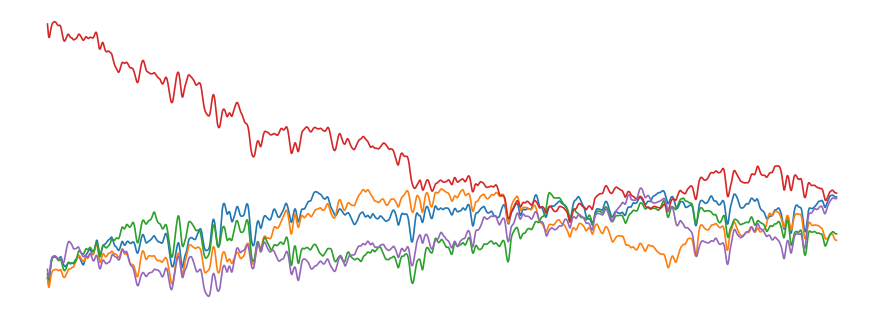

In [21]:
fs = 1/(Params.dt/second)  # Sampling frequency
kk = 0
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):   
    t = np.arange(len(mon_N_PC_BCM.new_weight[jj]))/fs
    signala = mon_N_PC_BCM.new_weight[jj] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala)
    plt.plot(t, output, label="new_weight dendrite "+str(kk+1)+' filtered')
    kk += 1
ylabel('Weight [-]')
xlabel('Time [ms]')
# title('Weights During and After BCM for PC '+str(ii+1))
# legend(loc='upper right')
plt.axis('off')
show()

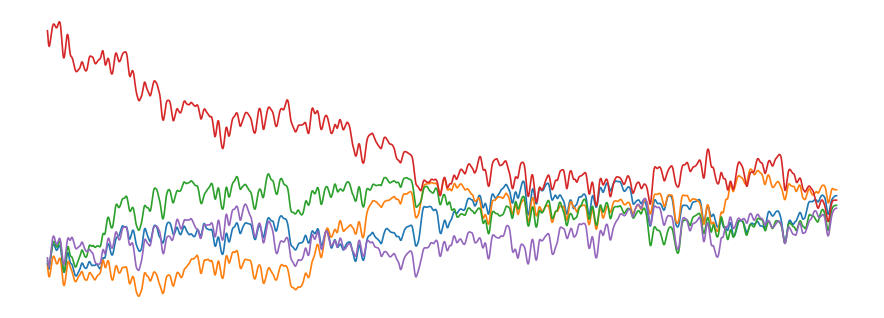

In [22]:
kk = 0
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):   
    t = np.arange(len(mon_N_PC_Coupled_BCM.new_weight[jj]))/fs
    signala = mon_N_PC_Coupled_BCM.new_weight[jj] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala)
    plt.plot(t, output, label="new_weight dendrite "+str(kk+1)+' filtered')
    kk += 1
ylabel('Weight [-]')
xlabel('Time [ms]')
# title('Weights During and After BCM for PC '+str(ii+1))
# legend(loc='upper right')
plt.axis('off')
show()